# Healthcare Insurance Fraud Detection

Binary classification model predicting fraudulent healthcare claims from a synthetic
dataset of ~10,000 claims. Full write-up and results summary: see README.md.

## 1. Load Data

In [1]:
import pandas as pd 
import numpy as np 

In [2]:
df=pd.read_csv('healthcare_fraud_detection.csv')

In [3]:
df.head(10)

,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0
2,P0140,C0000002,78,Female,J06.9,93000,591.69,530.06,Medicaid,2022-04-11,29,60,Cardiology,IL,Pending,0,5,Inpatient,1,3.0
3,P0202,C0000003,65,Male,I10,93000,235.15,189.11,Private,2023-10-11,22,70,General Practice,TX,Approved,0,0,Emergency,0,5.0
4,P0135,C0000004,36,Male,M54.5,85025,487.96,369.91,Private,2023-09-05,21,67,Pulmonology,PA,Approved,0,5,Inpatient,0,4.0
5,P0241,C0000005,44,Female,E11.9,80053,220.99,174.05,Medicaid,2024-12-20,26,74,Orthopedics,CA,Approved,0,2,Emergency,0,1.0
6,P0196,C0000006,50,Male,E78.5,93000,458.60,372.31,Medicare,2022-02-20,2,84,Cardiology,OH,Approved,0,0,Outpatient,1,0.0
7,P0071,C0000007,1,Male,I10,85025,934.34,321.60,NaN,2022-07-13,6,114,NaN,PA,Pending,1,2,Emergency,0,NaN
8,P0097,C0000008,34,Female,M54.5,97110,478.11,412.48,Medicare,2021-05-25,24,65,Pulmonology,IL,Pending,0,5,Inpatient,1,4.0
9,P0125,C0000009,47,Male,K21.9,99213,426.16,335.80,Self-Pay,2022-05-29,5,56,Internal Medicine,TX,Approved,0,2,Emergency,0,4.0


In [4]:
df.columns.tolist()  

['Provider_ID',
 'Claim_ID',
 'Patient_Age',
 'Patient_Gender',
 'Diagnosis_Code',
 'Procedure_Code',
 'Claim_Amount',
 'Approved_Amount',
 'Insurance_Type',
 'Claim_Submission_Date',
 'Days_Between_Service_and_Claim',
 'Number_of_Claims_Per_Provider_Monthly',
 'Provider_Specialty',
 'Patient_State',
 'Claim_Status',
 'Is_Fraud',
 'Length_of_Stay',
 'Visit_Type',
 'Chronic_Condition_Flag',
 'Prior_Visits_12m']

## 2. Handle Missing Values

Before filling any missing values, check whether missingness itself correlates
with fraud — if it does, that's a pattern worth preserving rather than erasing.

In [5]:
df.isnull().sum()

Provider_ID                                0
Claim_ID                                   0
Patient_Age                                0
Patient_Gender                             0
Diagnosis_Code                             0
Procedure_Code                             0
Claim_Amount                               0
Approved_Amount                            0
Insurance_Type                           350
Claim_Submission_Date                      0
Days_Between_Service_and_Claim             0
Number_of_Claims_Per_Provider_Monthly      0
Provider_Specialty                       350
Patient_State                              0
Claim_Status                               0
Is_Fraud                                   0
Length_of_Stay                             0
Visit_Type                                 0
Chronic_Condition_Flag                     0
Prior_Visits_12m                         350
dtype: int64

In [6]:
#  here we check if missing data was happen due to transfer or related to each other such as same row
mask = df['Insurance_Type'].isnull()
df[mask][['Provider_Specialty','Prior_Visits_12m']].isnull().sum() 

Provider_Specialty    15
Prior_Visits_12m      12
dtype: int64

In [7]:
df.groupby(df['Insurance_Type'].isnull())['Is_Fraud'].mean()

Insurance_Type
False    0.083316
True     0.071429
Name: Is_Fraud, dtype: float64

In [8]:
df['Insurance_Type']=df['Insurance_Type'].fillna('Unknown')

In [9]:
df.groupby(df['Prior_Visits_12m'].isnull())['Is_Fraud'].mean()

Prior_Visits_12m
False    0.082902
True     0.082857
Name: Is_Fraud, dtype: float64

In [10]:
df['Prior_Visits_12m'] = df['Prior_Visits_12m'].fillna(df['Prior_Visits_12m'].median())

In [11]:
# 1. Build a lookup: each provider → their known specialty
lookup = (df.dropna(subset=['Provider_Specialty'])
            .groupby('Provider_ID')['Provider_Specialty']
            .first())

# 2. Fill blanks from the lookup, then "Unknown" for the rest
df['Provider_Specialty'] = df['Provider_Specialty'].fillna(df['Provider_ID'].map(lookup))
df['Provider_Specialty'] = df['Provider_Specialty'].fillna('Unknown')

In [12]:
df.isnull().sum()

Provider_ID                              0
Claim_ID                                 0
Patient_Age                              0
Patient_Gender                           0
Diagnosis_Code                           0
Procedure_Code                           0
Claim_Amount                             0
Approved_Amount                          0
Insurance_Type                           0
Claim_Submission_Date                    0
Days_Between_Service_and_Claim           0
Number_of_Claims_Per_Provider_Monthly    0
Provider_Specialty                       0
Patient_State                            0
Claim_Status                             0
Is_Fraud                                 0
Length_of_Stay                           0
Visit_Type                               0
Chronic_Condition_Flag                   0
Prior_Visits_12m                         0
dtype: int64

**Note:** `Provider_ID` is dropped here. Earlier EDA (not shown in this notebook)
found real fraud-rate variation by provider (up to 42% for some providers vs. an
8% baseline) — but raw provider IDs can't be one-hot encoded (300+ unique values)
and a naive per-provider fraud rate leaks the label. Provider-level behavioral
features (e.g. claim volume, avg claim amount) are a documented next step — see
    README "Next Steps."

In [13]:
df=df.drop(columns=['Provider_ID'])

## 3. Feature Engineering — Date Features

Extracting month, day-of-week, and year from the raw submission date, since a raw
timestamp can't be used directly by the model.

In [14]:
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'])

In [15]:
df['Claim_Month']=df['Claim_Submission_Date'].dt.month

In [16]:
df['Claim_Day']=df['Claim_Submission_Date'].dt.weekday

In [17]:
df.groupby('Claim_Day')['Is_Fraud'].mean()

Claim_Day
0    0.079187
1    0.083969
2    0.085106
3    0.077032
4    0.090975
5    0.077191
6    0.086927
Name: Is_Fraud, dtype: float64

In [18]:
df['Claim_Year']=df['Claim_Submission_Date'].dt.year

# 4. Removing Data Leakage

Three columns are dropped here because they leak information not actually
available at the moment a new claim needs to be scored:

- **`Approved_Amount`** — only exists after a claim has already been processed/decided.
- **`Claim_Status`** — approval/denial is typically decided at or after the fraud
  determination, so it's close to a disguised version of the label itself.
- **`Claim_ID`** — a unique row identifier with no predictive meaning.

**`Days_Between_Service_and_Claim` is dropped separately (cell 23) for a different
reason:** EDA showed claims filed within 0–7 days had a 29% fraud rate, while every
other filing-delay bucket had *exactly* 0% fraud — an unrealistically clean cliff
that looked like a synthetic-data artifact rather than a real-world pattern. A model
trained with this column got a suspiciously high 0.96 ROC-AUC, driven almost
entirely by this one feature (coefficient 6x larger than any other). Dropping it
gives an honest baseline: 0.81 ROC-AUC, 0.69 recall. Full comparison in README.

In [19]:
df=df.drop(columns=['Approved_Amount','Claim_Submission_Date'])

In [20]:
df=df.drop(columns=['Claim_Status'])

In [21]:
df=df.drop(columns=['Claim_ID'])

In [22]:
df=df.drop(columns=['Days_Between_Service_and_Claim'])

In [23]:
df.columns.tolist()  

['Patient_Age',
 'Patient_Gender',
 'Diagnosis_Code',
 'Procedure_Code',
 'Claim_Amount',
 'Insurance_Type',
 'Number_of_Claims_Per_Provider_Monthly',
 'Provider_Specialty',
 'Patient_State',
 'Is_Fraud',
 'Length_of_Stay',
 'Visit_Type',
 'Chronic_Condition_Flag',
 'Prior_Visits_12m',
 'Claim_Month',
 'Claim_Day',
 'Claim_Year']

In [24]:
df['Patient_Gender']=df['Patient_Gender'].map({'Male':1,'Female':0})

In [25]:
df['Diagnosis_Code'].map(df['Diagnosis_Code'].value_counts())

0       1025
1       1026
2        955
3        951
4       1055
        ... 
9995    1027
9996    1004
9997     998
9998     951
9999     943
Name: Diagnosis_Code, Length: 10000, dtype: int64

## quick check: confirm categories are low-cardinality (<15) before choosing one-hot encoding


In [26]:
df['Patient_State'].unique()



array(['NY', 'IL', 'TX', 'PA', 'CA', 'OH', 'FL', 'GA'], dtype=object)

In [27]:
df['Procedure_Code'].unique()


array([36415, 99213, 93000, 85025, 80053, 97110, 71046, 87086, 99214])

In [28]:
df['Diagnosis_Code'].unique()

array(['I25.10', 'E11.9', 'J06.9', 'I10', 'M54.5', 'E78.5', 'K21.9',
       'F41.9', 'N39.0', 'J18.9'], dtype=object)

In [29]:
df['Provider_Specialty'].unique()

array(['Cardiology', 'General Practice', 'Pulmonology', 'Orthopedics',
       'Neurology', 'Internal Medicine'], dtype=object)

In [30]:
df['Insurance_Type'].unique()

array(['Medicaid', 'Self-Pay', 'Private', 'Medicare', 'Unknown'],
      dtype=object)

In [31]:
df['Visit_Type'].unique()

array(['Outpatient', 'Inpatient', 'Emergency'], dtype=object)

In [32]:
df['Claim_Year'].unique()

array([2024, 2022, 2023, 2021, 2025])

In [33]:
df.groupby('Claim_Year')['Is_Fraud'].agg(['count','mean'])

,count,mean
Claim_Year,,
2021,2413,0.085785
2022,2571,0.082069
2023,2481,0.087062
2024,2436,0.079639
2025,99,0.010101


In [34]:
# Claim_Year created earlier alongside Claim_Month/Claim_Day; dropped here after
# checking fraud rate by year (see EDA above) — flat ~8% across 2021-2024, and
# 2025 has too few claims (99 vs ~2,400+ in other years) to trust its rate.
df = df.drop(columns=['Claim_Year'])

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report

In [36]:
x=df.drop(columns=['Is_Fraud',])
y=df['Is_Fraud']

## 5. Train/Test Split
Split before any encoding or scaling, so those steps can be fit on training data only — avoiding any leakage of test-set statistics into training.

In [37]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

## 6. Encoding Categorical Features
Binary columns (gender, chronic flag) are mapped to 0/1. Low-cardinality categorical columns (confirmed via .unique() checks below — all under 15 categories) are one-hot encoded, including numerically-stored codes like Procedure_Code, which are labels, not real quantities, despite looking numeric.

In [38]:

cat_cols=['Diagnosis_Code','Procedure_Code','Insurance_Type','Provider_Specialty','Patient_State','Claim_Month',
 'Claim_Day']

encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
encoder.fit(x_train[cat_cols])
x_train_encoded=encoder.transform(x_train[cat_cols])
x_test_encoded=encoder.transform(x_test[cat_cols])

In [39]:
#scaling 
numeric_cols=['Patient_Age',
 'Patient_Gender',
 'Claim_Amount',
 'Number_of_Claims_Per_Provider_Monthly',
 'Length_of_Stay',
 'Chronic_Condition_Flag',
 'Prior_Visits_12m']

scaler=StandardScaler()
scaler.fit(x_train[numeric_cols])
x_train_scaled=scaler.transform(x_train[numeric_cols])
x_test_scaled=scaler.transform(x_test[numeric_cols])

## 7. Model Training — Random Forest

`class_weight='balanced'` addresses the ~8% fraud imbalance. `max_depth=5` was
chosen after comparing against `max_depth=10`, which overfit (train recall 0.76
vs. test recall 0.43); depth=5 closed most of that gap.

In [40]:
##combined the scale and encoded 

x_train_final=np.hstack([x_train_scaled,x_train_encoded])
x_test_final=np.hstack([x_test_scaled,x_test_encoded])


In [41]:
x_train_final.shape[1]

64

In [42]:
model=RandomForestClassifier(class_weight='balanced',n_estimators=1000,max_depth=5,random_state=42)
model.fit(x_train_final,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, n_estimators=1000,
                       random_state=42)

## 8. Cross-Validation

A single train/test split can be misleading with only ~166 fraud cases in the
test set. 5-fold cross-validation gives a more reliable performance estimate.

In [43]:
from sklearn.model_selection import cross_val_score

rf_scores = cross_val_score(model, x_train_final, y_train, cv=5, scoring='recall')

print("RF recall (5-fold):", rf_scores.mean(), rf_scores.std())

RF recall (5-fold): 0.6350079744816587 0.006781553950629664


In [44]:
y_pred=model.predict(x_test_final)
y_proba=model.predict_proba(x_test_final)[:,1]

from sklearn.metrics import confusion_matrix,classification_report,roc_auc_score,average_precision_score
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
print('ROC-AUC:',roc_auc_score(y_test,y_proba))
print('PR-AUC:',average_precision_score(y_test,y_proba))

[[1349  485]
 [  48  118]]
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      1834
           1       0.20      0.71      0.31       166

    accuracy                           0.73      2000
   macro avg       0.58      0.72      0.57      2000
weighted avg       0.90      0.73      0.79      2000

ROC-AUC: 0.8007876653834531
PR-AUC: 0.33586683514753335


In [45]:
from sklearn.metrics import classification_report
train_report = classification_report(y_train, model.predict(x_train_final), output_dict=True)
test_report = classification_report(y_test, y_pred, output_dict=True)

print("Train recall (fraud):", train_report['1']['recall'])
print("Test recall (fraud):", test_report['1']['recall'])


Train recall (fraud): 0.722473604826546
Test recall (fraud): 0.7108433734939759


## 9. Threshold Tuning

The default 0.5 cutoff is arbitrary. Testing several thresholds shows the
precision/recall tradeoff explicitly, rather than accepting 0.5 without checking.

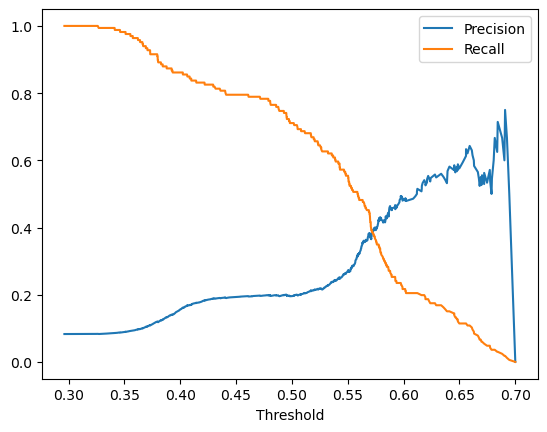

In [46]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [47]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"Threshold {t}:")
    print(classification_report(y_test, y_pred_t))

Threshold 0.3:
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      1834
           1       0.08      1.00      0.15       166

    accuracy                           0.08      2000
   macro avg       0.54      0.50      0.08      2000
weighted avg       0.92      0.08      0.01      2000

Threshold 0.4:
              precision    recall  f1-score   support

           0       0.98      0.58      0.73      1834
           1       0.16      0.86      0.26       166

    accuracy                           0.60      2000
   macro avg       0.57      0.72      0.50      2000
weighted avg       0.91      0.60      0.69      2000

Threshold 0.5:
              precision    recall  f1-score   support

           0       0.97      0.74      0.84      1834
           1       0.20      0.71      0.31       166

    accuracy                           0.73      2000
   macro avg       0.58      0.72      0.57      2000
weighted avg       0.90      

## 10. Save Model for Deployment

Saving the fitted model, scaler, and encoder so a new claim can be scored without
retraining. All three are `.transform()`-only at prediction time — never re-fit.

In [48]:
import joblib
import os
os.makedirs('models', exist_ok=True)

joblib.dump(model, 'models/fraud_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(encoder, 'models/onehot_encoder.pkl')

['models/onehot_encoder.pkl']

In [49]:
def predict_fraud(new_claim_df, model, scaler, encoder, numeric_cols, cat_cols):
    # same numeric scaling
    scaled = scaler.transform(new_claim_df[numeric_cols])
    # same categorical encoding
    encoded = encoder.transform(new_claim_df[cat_cols])
    # same combination
    features = np.hstack([scaled, encoded])
    # predict
    proba = model.predict_proba(features)[:, 1]
    pred = (proba >= 0.5).astype(int)  # or your chosen threshold from the tuning step
    return pred, proba

In [50]:
# Simulate a fresh deployment environment: load the saved artifacts from disk only,
# with no dependency on objects already in memory from the training session above.

model_loaded = joblib.load('fraud_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')
encoder_loaded = joblib.load('onehot_encoder.pkl')

# Validation check: confirm the reloaded artifacts reproduce correct predictions
# on a sample of known test rows before considering the pipeline deployment-ready.
sample = x_test.iloc[:3]
preds, probs = predict_fraud(sample, model_loaded, scaler_loaded, encoder_loaded, numeric_cols, cat_cols)
print(preds, probs)

[0 0 1] [0.37058117 0.41085592 0.67721032]
